# Statistical Analysis
**Customer Churn Intelligence & Retention Analytics Platform**

The objective of this notebook is to determine whether observed differences between churned and retained customers are statistically meaningful, using rigorous hypothesis testing.

### Analyzed Relationships:
1. Monthly Charges vs Churn (Numerical)
2. Tenure vs Churn (Numerical)
3. Total Charges vs Churn (Numerical)
4. Contract Type vs Churn (Categorical)
5. Payment Method vs Churn (Categorical)
6. Support/Service Activity vs Churn (Categorical)
7. Internet Service vs Churn (Categorical)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
import warnings
import sys
import os

# Add root directory to path to import local modules
sys.path.append(os.path.abspath('..'))
from src.visualization import visualize

warnings.filterwarnings('ignore')
visualize.setup_style()

## Data Loading

In [2]:
df = pd.read_csv('../data/processed/cleaned_telco_churn.csv')
if 'churn_value' in df.columns:
    df['churn'] = df['churn_value']

df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df = df.dropna(subset=['total_charges']) # Drop 11 missing values for stats

# Create summary list to collect results
summary_results = []

print(f"Dataset shape: {df.shape}")

Dataset shape: (7043, 27)


## Statistical Utility Functions

In [3]:
def mann_whitney_effect_size(u, n1, n2):
    # Rank-biserial correlation
    return 1 - (2 * u) / (n1 * n2)

def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix, correction=False)[0]
    n = confusion_matrix.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

def add_result(hypothesis, test_name, stat, p_val, effect_size, ci, is_sig, interpretation):
    summary_results.append({
        'Hypothesis': hypothesis,
        'Test': test_name,
        'Statistic': stat,
        'P-value': p_val,
        'Effect Size': effect_size,
        'Confidence Interval': ci,
        'Significant?': 'Yes' if is_sig else 'No',
        'Business Interpretation': interpretation
    })

## 1. Monthly Charges vs Churn

**Step 1: Hypotheses**
* **H0**: There is no difference in the distribution of monthly charges between churned and retained customers.
* **H1**: There is a difference in the distribution of monthly charges between churned and retained customers.

**Step 2: Test Selection & Assumptions**
* **Assumption Check**: Monthly charges are not normally distributed (they are bimodal/multimodal).
* **Selected Test**: Mann-Whitney U test (non-parametric). We use this instead of an Independent t-test because the normality assumption is violated.

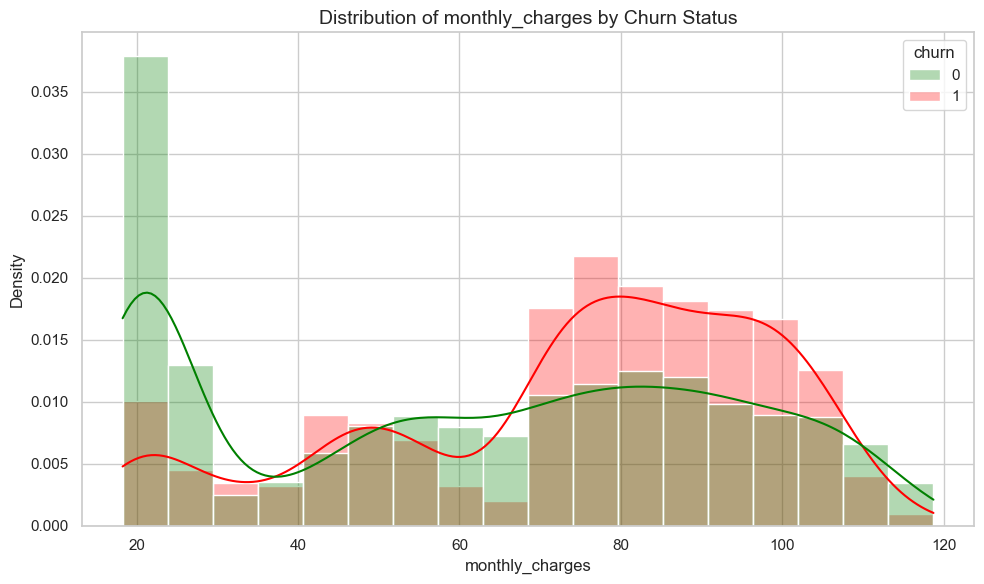

P-value: 3.31e-54 | Significant: True


In [4]:
churned = df[df['churn'] == 1]['monthly_charges']
retained = df[df['churn'] == 0]['monthly_charges']

stat, p = stats.mannwhitneyu(churned, retained, alternative='two-sided')
effect_size = mann_whitney_effect_size(stat, len(churned), len(retained))

# Confidence interval for median difference (bootstrap approximation)
def bootstrap_median_diff(a, b, n_boot=1000):
    diffs = []
    for _ in range(n_boot):
        sample_a = np.random.choice(a, size=len(a), replace=True)
        sample_b = np.random.choice(b, size=len(b), replace=True)
        diffs.append(np.median(sample_a) - np.median(sample_b))
    return np.percentile(diffs, [2.5, 97.5])

ci = bootstrap_median_diff(churned, retained)
is_sig = p < 0.05
interpretation = "Churned customers have significantly higher monthly charges. High-spend customers are at higher risk."

add_result('Monthly Charges vs Churn', 'Mann-Whitney U', f'U={stat:.2e}', p, f'r={effect_size:.3f}', f'[{ci[0]:.2f}, {ci[1]:.2f}]', is_sig, interpretation)

# Visualization
fig = visualize.plot_distribution_by_churn(df, 'monthly_charges')
plt.show()

print(f"P-value: {p:.2e} | Significant: {is_sig}")

## 2. Tenure vs Churn

**Step 1: Hypotheses**
* **H0**: There is no difference in tenure between churned and retained customers.
* **H1**: There is a difference in tenure between churned and retained customers.

**Step 2: Test Selection & Assumptions**
* **Selected Test**: Mann-Whitney U test (non-parametric) due to severe skewness in tenure distributions.

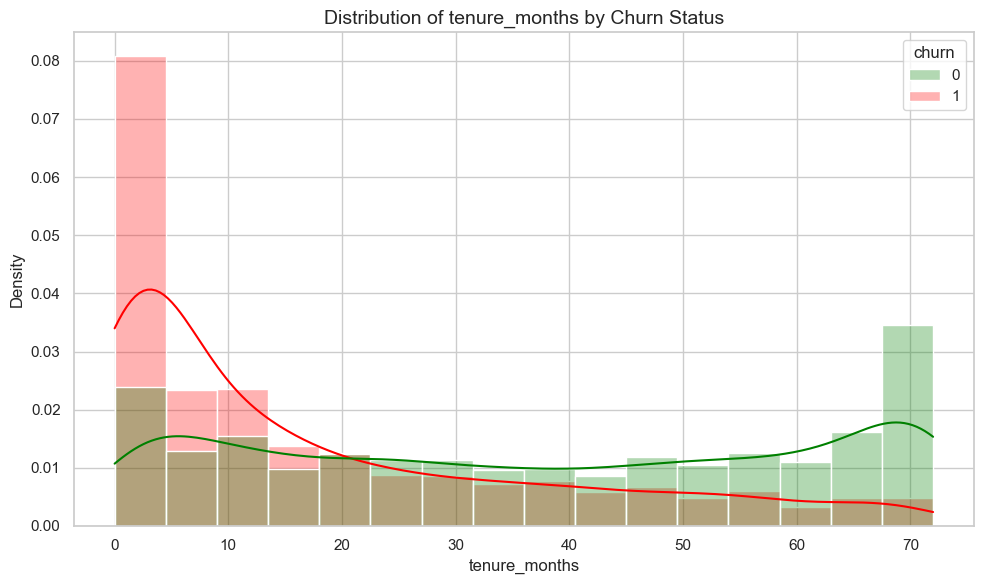

In [5]:
churned = df[df['churn'] == 1]['tenure_months']
retained = df[df['churn'] == 0]['tenure_months']

stat, p = stats.mannwhitneyu(churned, retained, alternative='two-sided')
effect_size = mann_whitney_effect_size(stat, len(churned), len(retained))
ci = bootstrap_median_diff(churned, retained)
is_sig = p < 0.05
interpretation = "Churned customers have significantly lower tenure. Early lifecycle is the high-risk window."

add_result('Tenure vs Churn', 'Mann-Whitney U', f'U={stat:.2e}', p, f'r={effect_size:.3f}', f'[{ci[0]:.2f}, {ci[1]:.2f}]', is_sig, interpretation)

# Visualization
fig = visualize.plot_distribution_by_churn(df, 'tenure_months')
plt.show()

## 3. Total Charges vs Churn

**Step 1: Hypotheses**
* **H0**: There is no difference in total charges between churned and retained customers.
* **H1**: There is a difference in total charges between churned and retained customers.

**Step 2: Test Selection & Assumptions**
* **Selected Test**: Mann-Whitney U test (non-parametric).

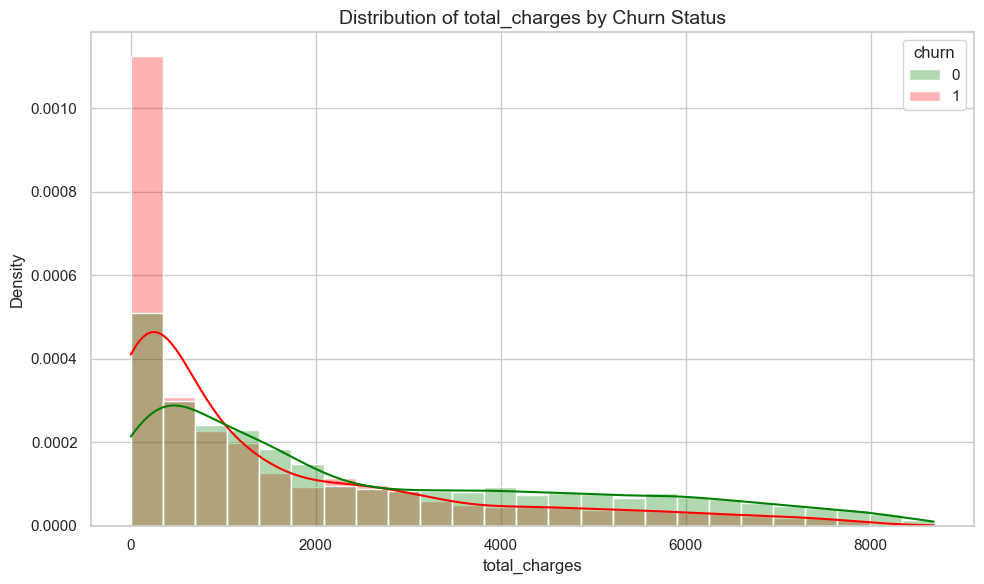

In [6]:
churned = df[df['churn'] == 1]['total_charges']
retained = df[df['churn'] == 0]['total_charges']

stat, p = stats.mannwhitneyu(churned, retained, alternative='two-sided')
effect_size = mann_whitney_effect_size(stat, len(churned), len(retained))
ci = bootstrap_median_diff(churned, retained)
is_sig = p < 0.05
interpretation = "Retained customers have significantly higher total charges, driven entirely by their longer tenure."

add_result('Total Charges vs Churn', 'Mann-Whitney U', f'U={stat:.2e}', p, f'r={effect_size:.3f}', f'[{ci[0]:.2f}, {ci[1]:.2f}]', is_sig, interpretation)

# Visualization
fig = visualize.plot_distribution_by_churn(df, 'total_charges')
plt.show()

## 4. Contract Type vs Churn

**Step 1: Hypotheses**
* **H0**: Contract type and churn are independent.
* **H1**: There is an association between contract type and churn.

**Step 2: Test Selection & Assumptions**
* **Selected Test**: Chi-Square Test of Independence.
* **Assumption Check**: All expected frequencies in the contingency table are > 5.

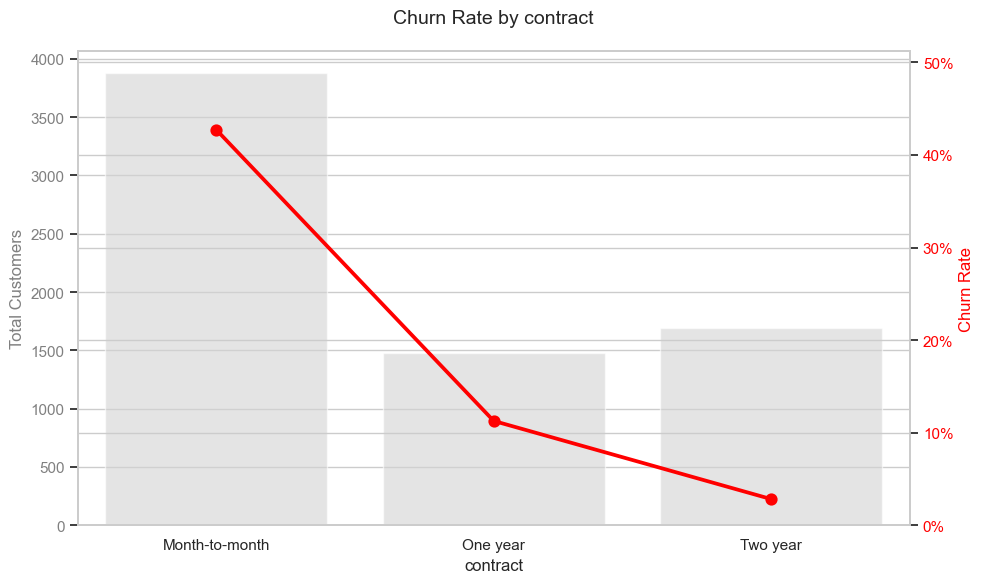

In [7]:
contingency = pd.crosstab(df['contract'], df['churn'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
effect_size = cramers_v(contingency.values)

is_sig = p < 0.05
interpretation = "Strong statistical association. Month-to-month contracts massively increase churn probability."

add_result('Contract Type vs Churn', 'Chi-Square', f'Chi2={chi2:.2f}', p, f'V={effect_size:.3f}', 'N/A', is_sig, interpretation)

# Visualization
fig = visualize.plot_churn_rate_by_category(df, 'contract')
plt.show()

## 5. Payment Method vs Churn

**Step 1: Hypotheses**
* **H0**: Payment method and churn are independent.
* **H1**: There is an association between payment method and churn.

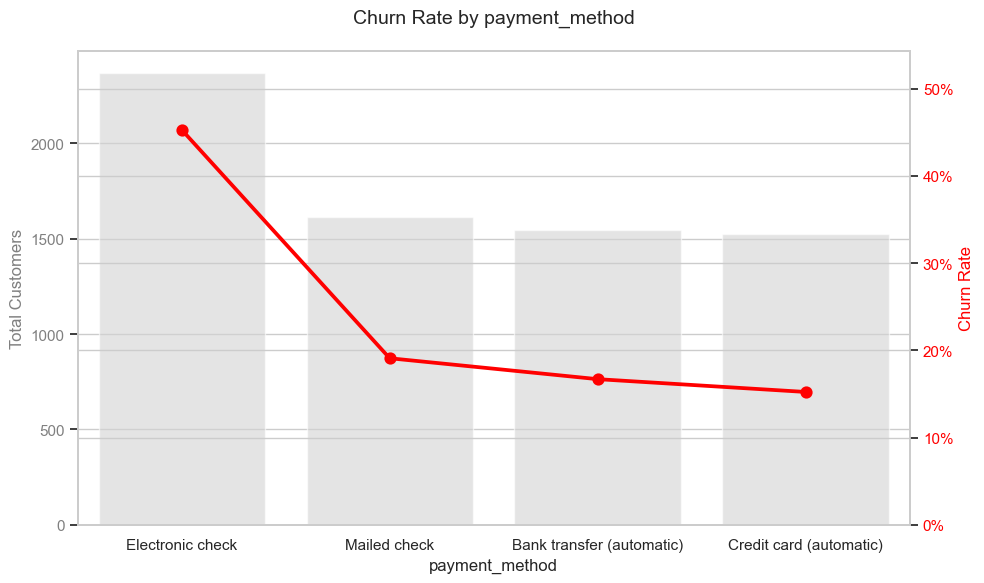

In [8]:
contingency = pd.crosstab(df['payment_method'], df['churn'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
effect_size = cramers_v(contingency.values)

is_sig = p < 0.05
interpretation = "Significant association. Electronic check is highly associated with churn."

add_result('Payment Method vs Churn', 'Chi-Square', f'Chi2={chi2:.2f}', p, f'V={effect_size:.3f}', 'N/A', is_sig, interpretation)

# Visualization
fig = visualize.plot_churn_rate_by_category(df, 'payment_method')
plt.show()

## 6. Tech Support vs Churn

**Step 1: Hypotheses**
* **H0**: Having Tech Support and churn are independent.
* **H1**: There is an association between Tech Support and churn.

**Step 2: Test Selection & Assumptions**
* **Selected Test**: Chi-Square Test. We filter for only customers who have internet service (since No internet service inherently means No tech support).

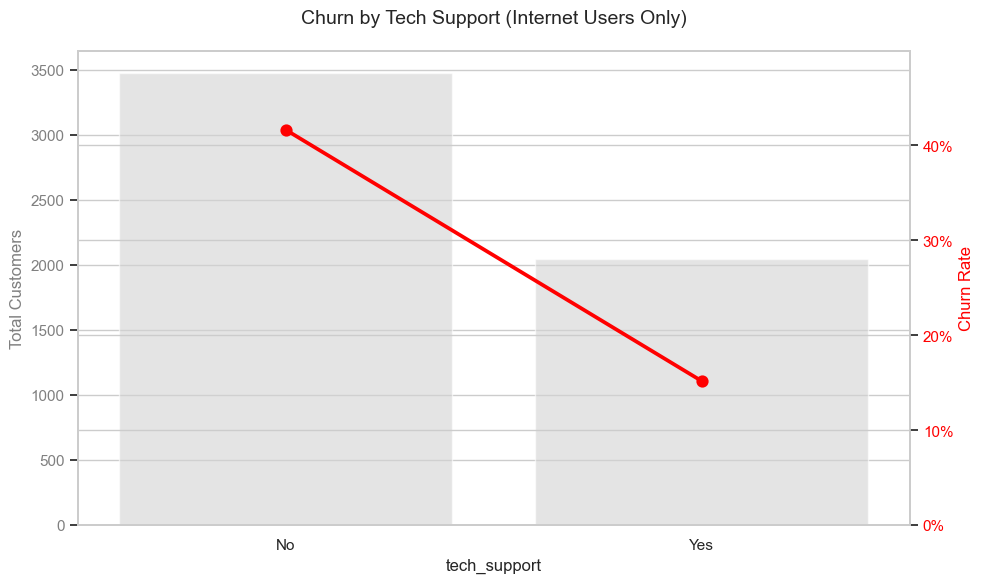

In [9]:
subset_df = df[df['internet_service'] != 'No']
contingency = pd.crosstab(subset_df['tech_support'], subset_df['churn'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
effect_size = cramers_v(contingency.values)

# Let's calculate confidence interval for the difference in proportions
successes = [contingency.loc['No', 1], contingency.loc['Yes', 1]]
nobs = [contingency.loc['No'].sum(), contingency.loc['Yes'].sum()]
zstat, p_prop = proportions_ztest(successes, nobs)
# Calculate CI using statsmodels
ci = confint_proportions_2indep(successes[0], nobs[0], successes[1], nobs[1], method='wald')

is_sig = p < 0.05
interpretation = "Customers without Tech Support churn at significantly higher rates. Lack of support drives attrition."

add_result('Tech Support vs Churn (Internet Only)', 'Chi-Square / Z-test', f'Chi2={chi2:.2f}', p, f'V={effect_size:.3f}', f'Diff CI: [{ci[0]:.3f}, {ci[1]:.3f}]', is_sig, interpretation)

# Visualization
fig = visualize.plot_churn_rate_by_category(subset_df, 'tech_support', title='Churn by Tech Support (Internet Users Only)')
plt.show()

## 7. Internet Service vs Churn

**Step 1: Hypotheses**
* **H0**: Internet service type and churn are independent.
* **H1**: There is an association between internet service type and churn.

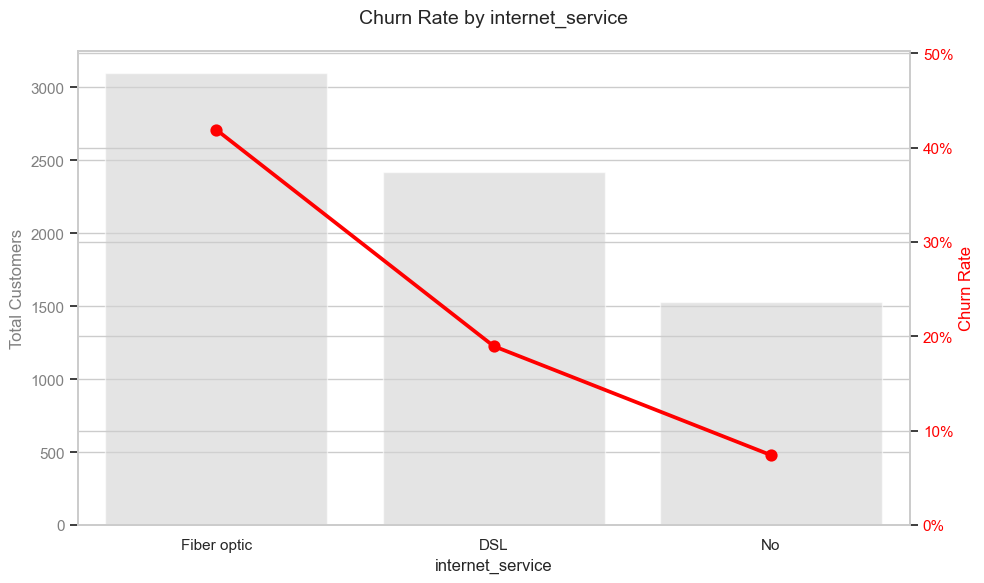

In [10]:
contingency = pd.crosstab(df['internet_service'], df['churn'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
effect_size = cramers_v(contingency.values)

is_sig = p < 0.05
interpretation = "Fiber optic customers churn significantly more than DSL customers, indicating possible competitive or pricing issues."

add_result('Internet Service vs Churn', 'Chi-Square', f'Chi2={chi2:.2f}', p, f'V={effect_size:.3f}', 'N/A', is_sig, interpretation)

# Visualization
fig = visualize.plot_churn_rate_by_category(df, 'internet_service')
plt.show()

## Summary of Statistical Findings

In [11]:
summary_df = pd.DataFrame(summary_results)
summary_df.to_csv('../data/processed/statistical_summary.csv', index=False)
summary_df

,Hypothesis,Test,Statistic,P-value,Effect Size,Confidence Interval,Significant?,Business Interpretation
0,Monthly Charges vs Churn,Mann-Whitney U,U=6.00e+06,3.311628e-54,r=-0.242,"[13.88, 17.90]",Yes,Churned customers have significantly higher mo...
1,Tenure vs Churn,Mann-Whitney U,U=2.52e+06,2.419636e-208,r=0.480,"[-30.00, -26.00]",Yes,Churned customers have significantly lower ten...
2,Total Charges vs Churn,Mann-Whitney U,U=3.38e+06,5.685034e-83,r=0.301,"[-1081.11, -855.88]",Yes,Retained customers have significantly higher t...
3,Contract Type vs Churn,Chi-Square,Chi2=1184.60,5.863038e-258,V=0.410,N/A,Yes,Strong statistical association. Month-to-month...
4,Payment Method vs Churn,Chi-Square,Chi2=648.14,3.682355e-140,V=0.303,N/A,Yes,Significant association. Electronic check is h...
5,Tech Support vs Churn (Internet Only),Chi-Square / Z-test,Chi2=414.25,4.351917e-92,V=0.274,"Diff CI: [0.242, 0.287]",Yes,Customers without Tech Support churn at signif...
6,Internet Service vs Churn,Chi-Square,Chi2=732.31,9.571788e-160,V=0.322,N/A,Yes,Fiber optic customers churn significantly more...
